In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


In [62]:
data = pd.read_csv('scholarship.csv')

In [63]:
data

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0
...,...,...,...
995,88.7,44,1
996,91.2,65,1
997,48.9,34,0
998,86.2,46,1


C:\Users\91958\AppData\Local\Temp\ipykernel_1760\2009143108.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['scholarship_exam_marks'])


<Axes: xlabel='scholarship_exam_marks', ylabel='Density'>

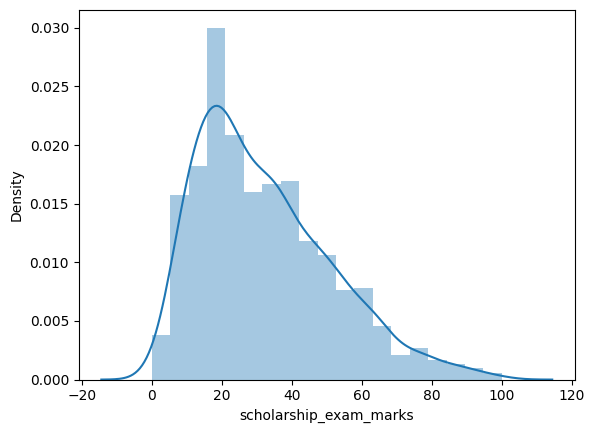

In [64]:
sns.distplot(data['scholarship_exam_marks'])

<Axes: ylabel='scholarship_exam_marks'>

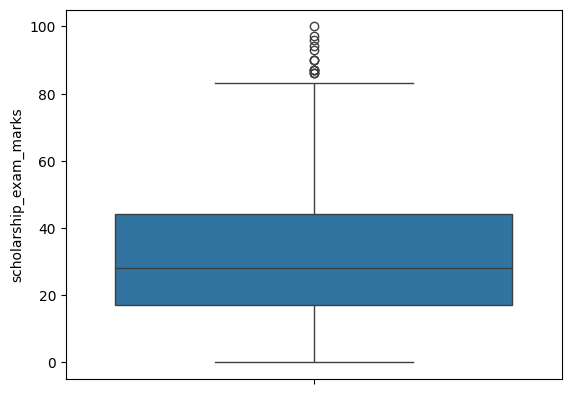

In [65]:
sns.boxplot(data['scholarship_exam_marks'])

In [66]:
data.describe()

,semester_percentage,scholarship_exam_marks,got_scholarship
count,1000.000000,1000.000000,1000.000000
mean,69.612400,32.225000,0.489000
std,6.158979,19.130822,0.500129
min,48.900000,0.000000,0.000000
25%,65.500000,17.000000,0.000000
50%,69.600000,28.000000,0.000000
75%,73.700000,44.000000,1.000000
max,91.200000,100.000000,1.000000


In [67]:
Q1 = data['scholarship_exam_marks'].quantile(.25)
Q3 = data['scholarship_exam_marks'].quantile(.75)


In [68]:
Q1

17.0

In [69]:
Q3

44.0

In [70]:
IQR = Q3 -Q1

In [71]:
IQR

27.0

In [72]:
higher = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

In [73]:
higher

84.5

In [74]:
lower

-23.5

## outlier detection

In [75]:
data[(data['scholarship_exam_marks'] < lower ) | (data['scholarship_exam_marks'] > higher)]

,semester_percentage,scholarship_exam_marks,got_scholarship
9,77.5,94,1
40,66.0,86,1
61,75.1,86,0
134,63.3,93,0
162,78.0,90,0
283,70.9,87,0
290,83.8,87,0
311,69.7,87,1
324,66.4,90,0
630,65.6,96,1


### trimming

In [76]:

new_data = data[(data["scholarship_exam_marks"]>lower) & (data["scholarship_exam_marks"]<higher)]

In [77]:
new_data

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0
...,...,...,...
995,88.7,44,1
996,91.2,65,1
997,48.9,34,0
998,86.2,46,1


<Axes: ylabel='scholarship_exam_marks'>

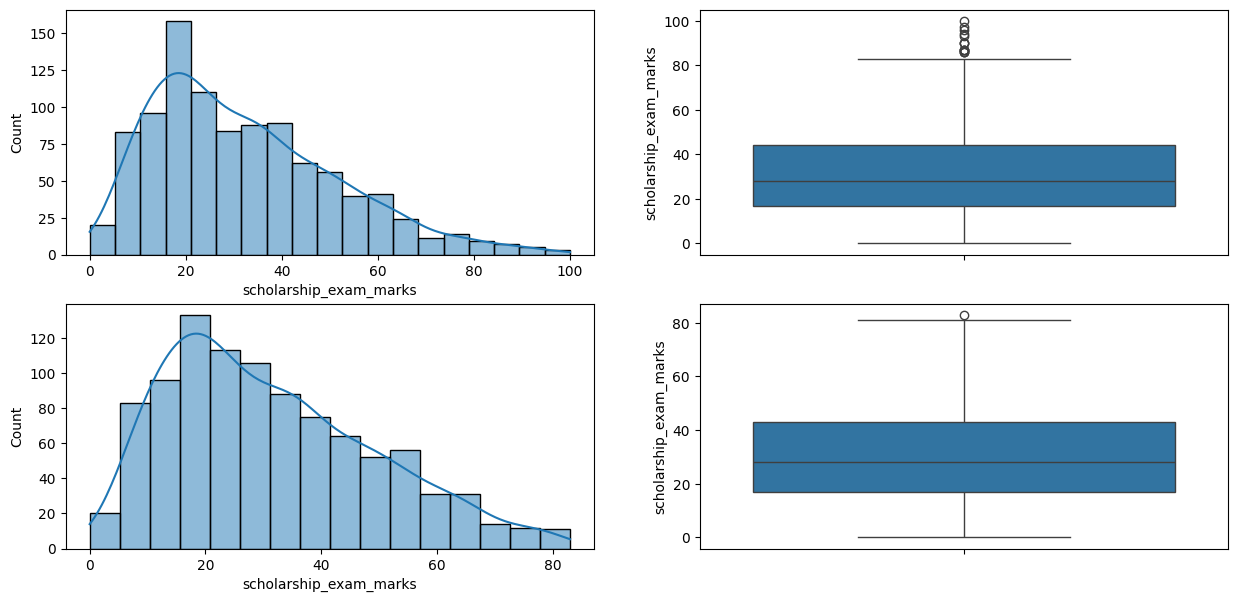

In [78]:
plt.figure(figsize=(15,7))
plt.subplot(2,2,1)
sns.histplot(data['scholarship_exam_marks'] , kde=True)

plt.subplot(2,2,2)
sns.boxplot(data['scholarship_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_data['scholarship_exam_marks'], kde=True)

plt.subplot(2,2,4)
sns.boxplot(new_data['scholarship_exam_marks'])

### capping

In [79]:
data['scholarship_exam_marks']  = data['scholarship_exam_marks'].clip(lower=lower , upper= higher)

In [80]:
data

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26.0,1
1,74.6,38.0,1
2,75.4,40.0,1
3,64.2,8.0,1
4,72.3,17.0,0
...,...,...,...
995,88.7,44.0,1
996,91.2,65.0,1
997,48.9,34.0,0
998,86.2,46.0,1


### no outlier

In [81]:
data[(data['scholarship_exam_marks'] < lower ) | data['scholarship_exam_marks'] > higher]

,semester_percentage,scholarship_exam_marks,got_scholarship


<Axes: ylabel='scholarship_exam_marks'>

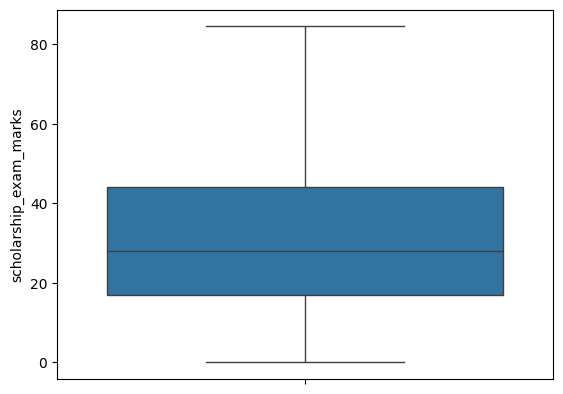

In [82]:
sns.boxplot(data['scholarship_exam_marks'])